# EDA · Pulso TransMi
Análisis exploratorio del conjunto público: integridad, faltantes, demanda, patrones por estación, clima, eventos y límites de interpretación.

**Objetivo:** entender los datos antes de limpiar o entrenar. No se imputan valores ni se eliminan observaciones. La demanda, el clima y los eventos son sintéticos; no describen necesariamente la operación real.

**Ejecución:** seleccionar un entorno con las dependencias de `requirements.txt` y ejecutar todas las celdas en orden. Se requiere conexión a la API. Los CSV se procesan en memoria; las gráficas quedan incorporadas en las salidas del notebook. El corte y los hashes se registran abajo. Una nueva ejecución puede consultar un corte distinto.

In [1]:
import io
import os
import ssl
import json
import hashlib
import platform
import time
import urllib.request
import urllib.error
from datetime import datetime, timezone

import certifi
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from IPython.display import display, Markdown

sns.set_theme(style="whitegrid", context="notebook", palette="colorblind")
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
BASE_URL = os.environ.get("PULSO_API_URL") or "https://pulso-transmi.72-60-245-2.sslip.io"
BASE_URL = BASE_URL.rstrip("/")
TZ = "America/Bogota"
print("Python:", platform.python_version(), "| pandas:", pd.__version__)
print("Fuente:", BASE_URL)

Matplotlib is building the font cache; this may take a moment.


Python: 3.12.10 | pandas: 3.0.5
Fuente: https://pulso-transmi.72-60-245-2.sslip.io


## 1. Ingesta verificable y diccionario
Se consultan metadatos antes y después de los CSV para detectar si el corte cambia durante la lectura. Cada archivo debe coincidir con su SHA-256. TLS permanece verificado.

- `stations`: ID textual, nombre, corredor y coordenadas.
- `observations`: estación, timestamp y demanda sintética por intervalo.
- `context`: timestamp, lluvia, temperatura, sus pronósticos e intensidad de eventos; no contiene estación.
- Los IDs conservan ceros iniciales y las fechas se convierten explícitamente a hora de Bogotá.
- La unidad operacional exacta de demanda, la emisión/horizonte de los pronósticos y el significado de la escala de eventos requieren aclaración del proveedor.

In [2]:
tls = ssl.create_default_context(cafile=certifi.where())
def read_public(path):
    request = urllib.request.Request(BASE_URL + path, headers={"User-Agent": "pulso-transmi-eda/1.0"})
    for attempt in range(3):
        try:
            with urllib.request.urlopen(request, timeout=45, context=tls) as response:
                return response.read()
        except urllib.error.HTTPError as exc:
            if exc.code not in (429, 500, 502, 503, 504) or attempt == 2:
                raise
        except (urllib.error.URLError, TimeoutError):
            if attempt == 2:
                raise
        time.sleep(2 ** attempt)

meta = json.loads(read_public("/v1/meta"))
frames, manifest = {}, []
for name in ("stations", "observations", "context"):
    filename = name + ".csv"
    raw = read_public("/v1/downloads/" + filename)
    actual = hashlib.sha256(raw).hexdigest()
    expected = meta["dataset"]["files"][filename]["sha256"]
    if actual != expected:
        raise ValueError(f"Hash inconsistente en {filename}; volver a consultar el corte.")
    frames[name] = pd.read_csv(io.BytesIO(raw), dtype={"station_id": "string"})
    manifest.append({"archivo": filename, "filas": len(frames[name]), "sha256": actual, "verificado": actual == expected})
meta_after = json.loads(read_public("/v1/meta"))
if meta["dataset"]["files"] != meta_after["dataset"]["files"]:
    raise RuntimeError("El conjunto cambió durante la lectura. Ejecutar nuevamente.")
stations, observations, context = [frames[k].copy() for k in ("stations", "observations", "context")]
fetched_at = datetime.now(timezone.utc).isoformat()
# Registrar solo metadatos necesarios; no reproducir parámetros internos del generador.
display(pd.Series({
    "consulta_utc": fetched_at, "api": meta.get("api_version"),
    "modo": meta.get("mode"), "dataset": meta["dataset"].get("dataset"),
    "inicio": meta["dataset"]["history_start"], "fin": meta["dataset"]["history_end"],
    "frecuencia_minutos": meta["dataset"]["frequency_minutes"],
    "demanda_sintetica": meta["dataset"].get("demand_is_synthetic")
}).to_frame("valor"))
display(pd.DataFrame(manifest))
for name, frame in frames.items():
    display(Markdown(f"**{name}**"))
    display(frame.head(3))

,valor
consulta_utc,2026-09-16T20:23:13.927068+00:00
api,0.2.0
modo,static-starter
dataset,pulso-transmi-starter-v1
inicio,2026-07-26T00:00:00-05:00
fin,2026-09-08T23:45:00-05:00
frecuencia_minutos,15
demanda_sintetica,True


,archivo,filas,sha256,verificado
0,stations.csv,12,d4dea46ceee2fb3ebe76362fbaa925c95b586130270c09...,True
1,observations.csv,51840,ecc6a32174f84e810c4b684db52f5e4eebd815f11f5e5b...,True
2,context.csv,4320,891f422628cc5033eaf89a1e8f7e69edab65afba1495a8...,True


**stations**

,station_id,station_name,corridor,latitude,longitude
0,03000,Portal Suba,Suba,4.747,-74.094
1,05000,Portal Américas,Américas,4.629,-74.173
2,09000,Portal Usme,Caracas,4.532,-74.119


**observations**

,observed_at,station_id,demand
0,2026-07-26 00:00:00-05:00,02300,56
1,2026-07-26 00:00:00-05:00,03000,84
2,2026-07-26 00:00:00-05:00,05000,104


**context**

,observed_at,rain_mm,rain_forecast,temperature_c,temperature_forecast,event_intensity
0,2026-07-26 00:00:00-05:00,0.000,0.924,9.470,8.493,0.000
1,2026-07-26 00:15:00-05:00,0.000,0.278,10.204,8.760,0.000
2,2026-07-26 00:30:00-05:00,0.000,0.754,8.017,9.172,0.000


## 2. Auditoría de calidad y cobertura
Se distinguen **celdas faltantes** de **filas ausentes**. La cobertura se compara con el producto de estaciones del catálogo y todos los intervalos declarados por la API, no solo con el mínimo y máximo observado.

Se comprueban vacíos, duplicados completos y por clave, conversiones inválidas, infinitos, IDs, coordenadas y rangos. Los rangos físicos amplios son señales de revisión, no reglas para borrar datos.

In [3]:
quality = []
for name, frame in frames.items():
    for col in frame.columns:
        blanks = frame[col].astype("string").str.strip().eq("").fillna(False).sum()
        quality.append({"tabla": name, "columna": col, "tipo_original": str(frame[col].dtype),
                        "nulos": int(frame[col].isna().sum()), "vacios": int(blanks),
                        "valores_distintos": frame[col].nunique(dropna=True)})
quality = pd.DataFrame(quality)
display(quality)

date_errors = {}
for name, frame in (("observations", observations), ("context", context)):
    parsed = pd.to_datetime(frame["observed_at"], utc=True, errors="coerce")
    date_errors[name] = int(parsed.isna().sum())
    frame["observed_at"] = parsed.dt.tz_convert(TZ)
numeric_columns = {
    "stations": ["latitude", "longitude"], "observations": ["demand"],
    "context": ["rain_mm", "rain_forecast", "temperature_c", "temperature_forecast", "event_intensity"]
}
numeric_errors = []
for name, frame in (("stations", stations), ("observations", observations), ("context", context)):
    for col in numeric_columns[name]:
        original = frame[col]
        numeric = pd.to_numeric(original, errors="coerce")
        numeric_errors.append({"tabla": name, "columna": col,
            "conversiones_invalidas": int((original.notna() & numeric.isna()).sum()),
            "infinitos": int(np.isinf(numeric).sum())})
        frame[col] = numeric
display(pd.DataFrame(numeric_errors))
grid = pd.date_range(meta["dataset"]["history_start"], meta["dataset"]["history_end"],
                     freq=f'{meta["dataset"]["frequency_minutes"]}min').tz_convert(TZ)
coverage = []
for sid in stations["station_id"].dropna().unique():
    times = observations.loc[observations.station_id.eq(sid), "observed_at"]
    coverage.append({"station_id": sid, "filas": len(times), "esperadas": len(grid),
        "intervalos_faltantes": len(grid.difference(times.dropna())),
        "fuera_de_grilla": int((times.notna() & ~times.isin(grid)).sum())})
coverage = pd.DataFrame(coverage).merge(stations[["station_id", "station_name"]], on="station_id")
checks = {
    "Nulos (todas las tablas)": int(quality.nulos.sum()),
    "Cadenas vacías": int(quality.vacios.sum()),
    "Fechas inválidas": sum(date_errors.values()),
    "Conversiones numéricas inválidas": sum(x["conversiones_invalidas"] for x in numeric_errors),
    "Valores infinitos": sum(x["infinitos"] for x in numeric_errors),
    "Duplicados completos": sum(int(f.duplicated().sum()) for f in frames.values()),
    "Claves estación/fecha duplicadas": int(observations.duplicated(["station_id", "observed_at"]).sum()),
    "IDs duplicados en catálogo": int(stations.station_id.duplicated().sum()),
    "Fechas de contexto duplicadas": int(context.observed_at.duplicated().sum()),
    "Intervalos faltantes de demanda": int(coverage.intervalos_faltantes.sum()),
    "Intervalos faltantes de contexto": len(grid.difference(context.observed_at.dropna())),
    "Demanda fuera de grilla": int(coverage.fuera_de_grilla.sum()),
    "Contexto fuera de grilla": int((context.observed_at.notna() & ~context.observed_at.isin(grid)).sum()),
    "Registros con estación desconocida": int((~observations.station_id.isin(stations.station_id)).sum()),
    "Demandas negativas": int(observations.demand.lt(0).sum()),
    "Demandas no enteras": int(observations.demand.dropna().mod(1).ne(0).sum()),
    "Coordenadas fuera de rango": int((~stations.latitude.between(-90, 90) | ~stations.longitude.between(-180, 180)).sum()),
    "Lluvia o pronóstico negativos": int((context[["rain_mm", "rain_forecast"]] < 0).sum().sum()),
    "Eventos fuera de [0, 1] (revisión)": int((~context.event_intensity.between(0, 1)).sum())
}
display(pd.Series(checks, name="registros_o_celdas").to_frame())
display(coverage)
print("Demanda igual a cero:", int(observations.demand.eq(0).sum()), "(no se considera un error por sí sola)")
for name, frame in frames.items():
    if len(frame) != meta["dataset"]["files"][name + ".csv"]["rows"]:
        raise ValueError(f"Conteo distinto de los metadatos: {name}")
blocking = [k for k in checks if k not in ("Demandas negativas", "Demandas no enteras",
            "Coordenadas fuera de rango", "Lluvia o pronóstico negativos", "Eventos fuera de [0, 1] (revisión)")]
if any(checks[k] for k in blocking):
    raise ValueError("La auditoría detectó problemas estructurales; revisar antes de continuar. No se corrigieron automáticamente.")

,tabla,columna,tipo_original,nulos,vacios,valores_distintos
0,stations,station_id,string,0,0,12
1,stations,station_name,str,0,0,12
2,stations,corridor,str,0,0,7
3,stations,latitude,float64,0,0,12
4,stations,longitude,float64,0,0,12
5,observations,observed_at,str,0,0,4320
6,observations,station_id,string,0,0,12
7,observations,demand,int64,0,0,1778
8,context,observed_at,str,0,0,4320
9,context,rain_mm,float64,0,0,4316


,tabla,columna,conversiones_invalidas,infinitos
0,stations,latitude,0,0
1,stations,longitude,0,0
2,observations,demand,0,0
3,context,rain_mm,0,0
4,context,rain_forecast,0,0
5,context,temperature_c,0,0
6,context,temperature_forecast,0,0
7,context,event_intensity,0,0


,registros_o_celdas
Nulos (todas las tablas),0
Cadenas vacías,0
Fechas inválidas,0
Conversiones numéricas inválidas,0
Valores infinitos,0
Duplicados completos,0
Claves estación/fecha duplicadas,0
IDs duplicados en catálogo,0
Fechas de contexto duplicadas,0
Intervalos faltantes de demanda,0


,station_id,filas,esperadas,intervalos_faltantes,fuera_de_grilla,station_name
0,03000,4320,4320,0,0,Portal Suba
1,05000,4320,4320,0,0,Portal Américas
2,09000,4320,4320,0,0,Portal Usme
3,02300,4320,4320,0,0,Calle 100 - Marketmedios
4,09122,4320,4320,0,0,Calle 72
5,05100,4320,4320,0,0,Banderas
6,07111,4320,4320,0,0,Ricaurte - NQS
7,06000,4320,4320,0,0,Portal El Dorado – C.C. NUESTRO BOGOTÁ
8,07107,4320,4320,0,0,Universidad Nacional
9,06111,4320,4320,0,0,Universidades – CityU


Demanda igual a cero: 0 (no se considera un error por sí sola)


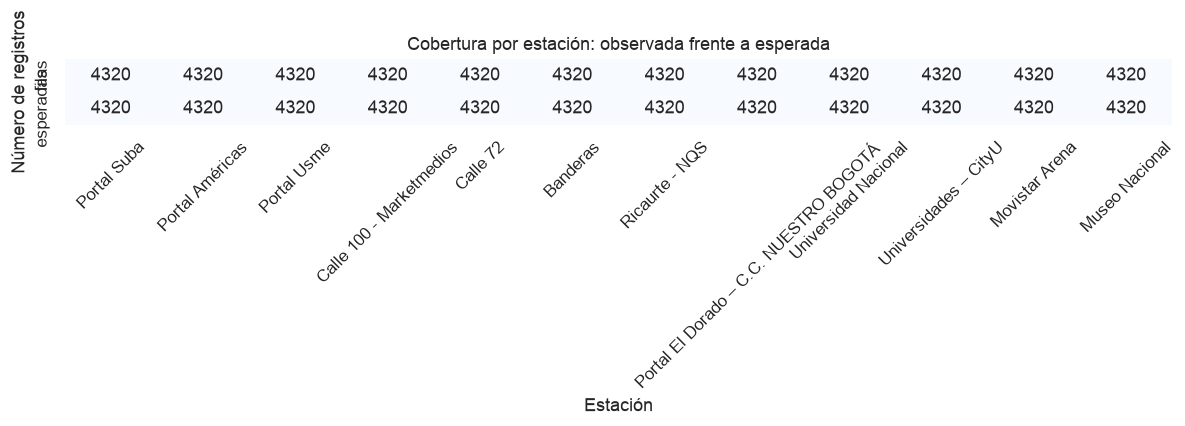

Conclusión del corte: sin faltantes estructurales; no requiere imputación.


In [4]:
fig, ax = plt.subplots(figsize=(11, 3.8))
matrix = coverage.set_index("station_name")[["filas", "esperadas"]].T
sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
ax.set(title="Cobertura por estación: observada frente a esperada", xlabel="Estación", ylabel="Número de registros")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()
print("Conclusión del corte:", "sin faltantes estructurales; no requiere imputación." if not any(checks[k] for k in blocking) else "revisar auditoría.")

## 3. Preparación para explorar
La unión demanda/contexto es muchos-a-uno por fecha; el catálogo es muchos-a-uno por ID. No se agregan estaciones entre sí al construir rezagos. Lunes–viernes no equivale necesariamente a días hábiles: no hay etiqueta de festivo.

In [5]:
obs = observations.sort_values(["station_id", "observed_at"]).reset_index(drop=True)
data = obs.merge(stations, on="station_id", how="left", validate="many_to_one")
data = data.merge(context, on="observed_at", how="left", validate="many_to_one")
assert len(data) == len(observations)
data["date"] = data.observed_at.dt.normalize()
data["dow"] = data.observed_at.dt.dayofweek
data["hour"] = data.observed_at.dt.hour
data["slot"] = data["hour"] * 4 + data.observed_at.dt.minute // 15
data["weekend"] = data.dow >= 5
data["day_type"] = np.where(data.weekend, "Sábado–domingo", "Lunes–viernes")
data["week_start"] = data["date"] - pd.to_timedelta(data.dow, unit="D")
names = stations.set_index("station_id").station_name.to_dict()
# Etiquetas abreviadas exclusivamente para legibilidad de gráficas.
short = {sid: name.replace(" – C.C. NUESTRO BOGOTÁ", "").replace(" - Marketmedios", "").replace(" – CityU", "") for sid, name in names.items()}
display(data.head())

,observed_at,station_id,demand,station_name,corridor,latitude,longitude,rain_mm,rain_forecast,temperature_c,temperature_forecast,event_intensity,date,dow,hour,slot,weekend,day_type,week_start
0,2026-07-26 00:00:00-05:00,02300,56,Calle 100 - Marketmedios,Autonorte,4.684,-74.058,0.000,0.924,9.470,8.493,0.000,2026-07-26 00:00:00-05:00,6,0,0,True,Sábado–domingo,2026-07-20 00:00:00-05:00
1,2026-07-26 00:15:00-05:00,02300,61,Calle 100 - Marketmedios,Autonorte,4.684,-74.058,0.000,0.278,10.204,8.760,0.000,2026-07-26 00:00:00-05:00,6,0,1,True,Sábado–domingo,2026-07-20 00:00:00-05:00
2,2026-07-26 00:30:00-05:00,02300,81,Calle 100 - Marketmedios,Autonorte,4.684,-74.058,0.000,0.754,8.017,9.172,0.000,2026-07-26 00:00:00-05:00,6,0,2,True,Sábado–domingo,2026-07-20 00:00:00-05:00
3,2026-07-26 00:45:00-05:00,02300,67,Calle 100 - Marketmedios,Autonorte,4.684,-74.058,0.000,0.000,9.581,11.030,0.000,2026-07-26 00:00:00-05:00,6,0,3,True,Sábado–domingo,2026-07-20 00:00:00-05:00
4,2026-07-26 01:00:00-05:00,02300,44,Calle 100 - Marketmedios,Autonorte,4.684,-74.058,0.000,0.000,8.651,7.992,0.000,2026-07-26 00:00:00-05:00,6,1,4,True,Sábado–domingo,2026-07-20 00:00:00-05:00


## 4. Distribución y diferencias entre estaciones
La demanda se mide aquí en **unidades sintéticas por estación e intervalo de 15 minutos**. Se muestran histograma y cajas; un punto extremo no es automáticamente un error.

,demanda
count,"51,840.000"
mean,356.523
std,319.469
min,14.000
1%,40.000
5%,65.000
25%,122.000
50%,263.000
75%,460.000
95%,"1,057.050"


,count,sum,mean,median,std,min,max,cv,participacion_pct,estacion
station_id,,,,,,,,,,
07111,4320,2953656,683.717,452.000,459.364,159,2284,0.672,15.981,Ricaurte - NQS
05100,4320,2553390,591.062,392.000,391.058,159,2065,0.662,13.815,Banderas
06000,4320,2207277,510.944,340.500,343.005,127,1789,0.671,11.943,Portal El Dorado – C.C. NUESTRO BOGOTÁ
05000,4320,1477690,342.058,201.000,288.811,59,1944,0.844,7.995,Portal Américas
10009,4320,1459817,337.921,266.000,270.661,50,1434,0.801,7.899,Museo Nacional
02300,4320,1269947,293.969,158.000,279.295,29,1472,0.950,6.871,Calle 100 - Marketmedios
07107,4320,1214046,281.029,248.000,198.734,17,982,0.707,6.569,Universidad Nacional
07105,4320,1177588,272.590,213.500,217.437,42,1313,0.798,6.371,Movistar Arena
03000,4320,1116400,258.426,153.000,216.827,48,1252,0.839,6.040,Portal Suba


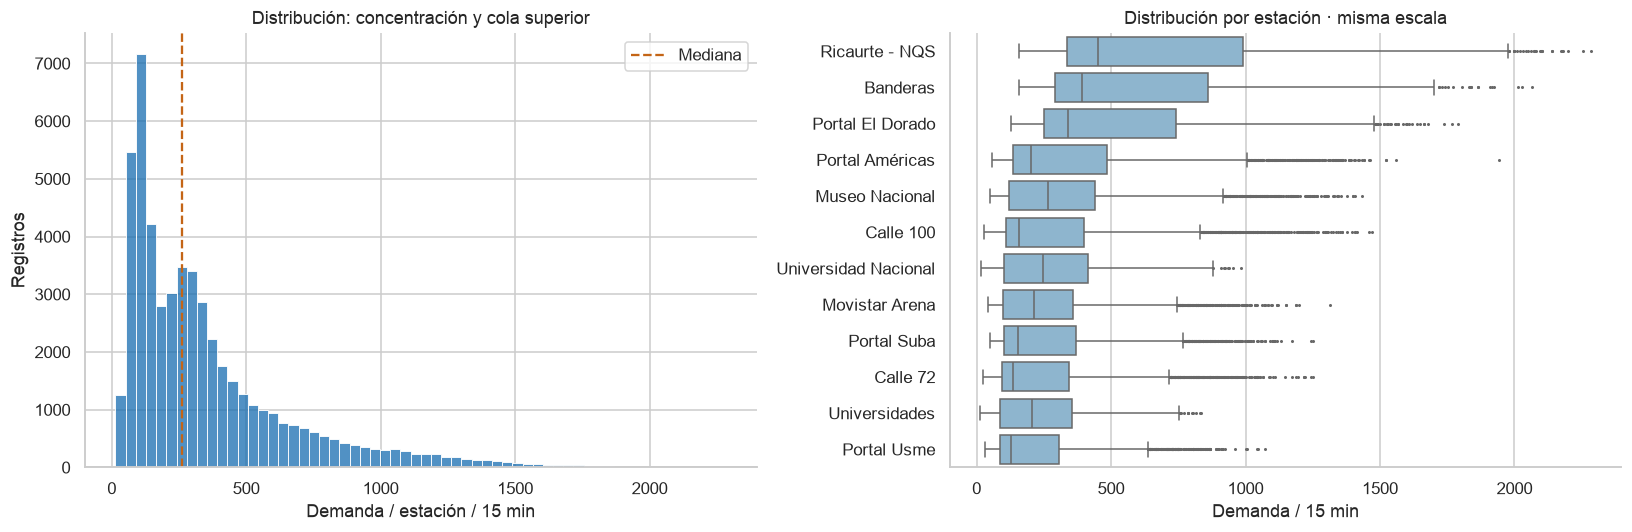

Las tres estaciones con mayor demanda concentran 41.7% del total.


In [6]:
summary = data.groupby("station_id").demand.agg(["count", "sum", "mean", "median", "std", "min", "max"])
summary["cv"] = summary["std"] / summary["mean"]
summary["participacion_pct"] = 100 * summary["sum"] / summary["sum"].sum()
summary["estacion"] = summary.index.map(names)
summary = summary.sort_values("mean", ascending=False)
display(data.demand.describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).to_frame("demanda"))
display(summary)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(data=data, x="demand", bins=60, ax=axes[0], color="#176cb0")
axes[0].set(title="Distribución: concentración y cola superior", xlabel="Demanda / estación / 15 min", ylabel="Registros")
axes[0].axvline(data.demand.median(), color="#c46516", linestyle="--", label="Mediana")
axes[0].legend()
order = summary.index.tolist()
sns.boxplot(data=data, y="station_id", x="demand", order=order, ax=axes[1], color="#83b7d9", fliersize=1)
axes[1].set_yticks(range(len(order)), [short[k] for k in order])
axes[1].set(title="Distribución por estación · misma escala", xlabel="Demanda / 15 min", ylabel="")
plt.tight_layout()
plt.show()
print(f"Las tres estaciones con mayor demanda concentran {summary.participacion_pct.head(3).sum():.1f}% del total.")

## 4.1. Mapa de estaciones y demanda promedio
Las coordenadas provienen del catálogo de la API. El **área de cada círculo** es proporcional a la demanda promedio por intervalo de 15 minutos. Los números identifican las estaciones en el listado lateral, ordenado por demanda.

El mapa base de calles es de **OpenStreetMap**; requiere conexión al ejecutar esta celda. Se consulta una pequeña cuadrícula de teselas y se compone en memoria usando la proyección Web Mercator, sin dependencias adicionales. La figura queda guardada en el notebook y puede verse después sin conexión. Los puntos representan estaciones individuales, no cobertura geográfica ni trazados de rutas.

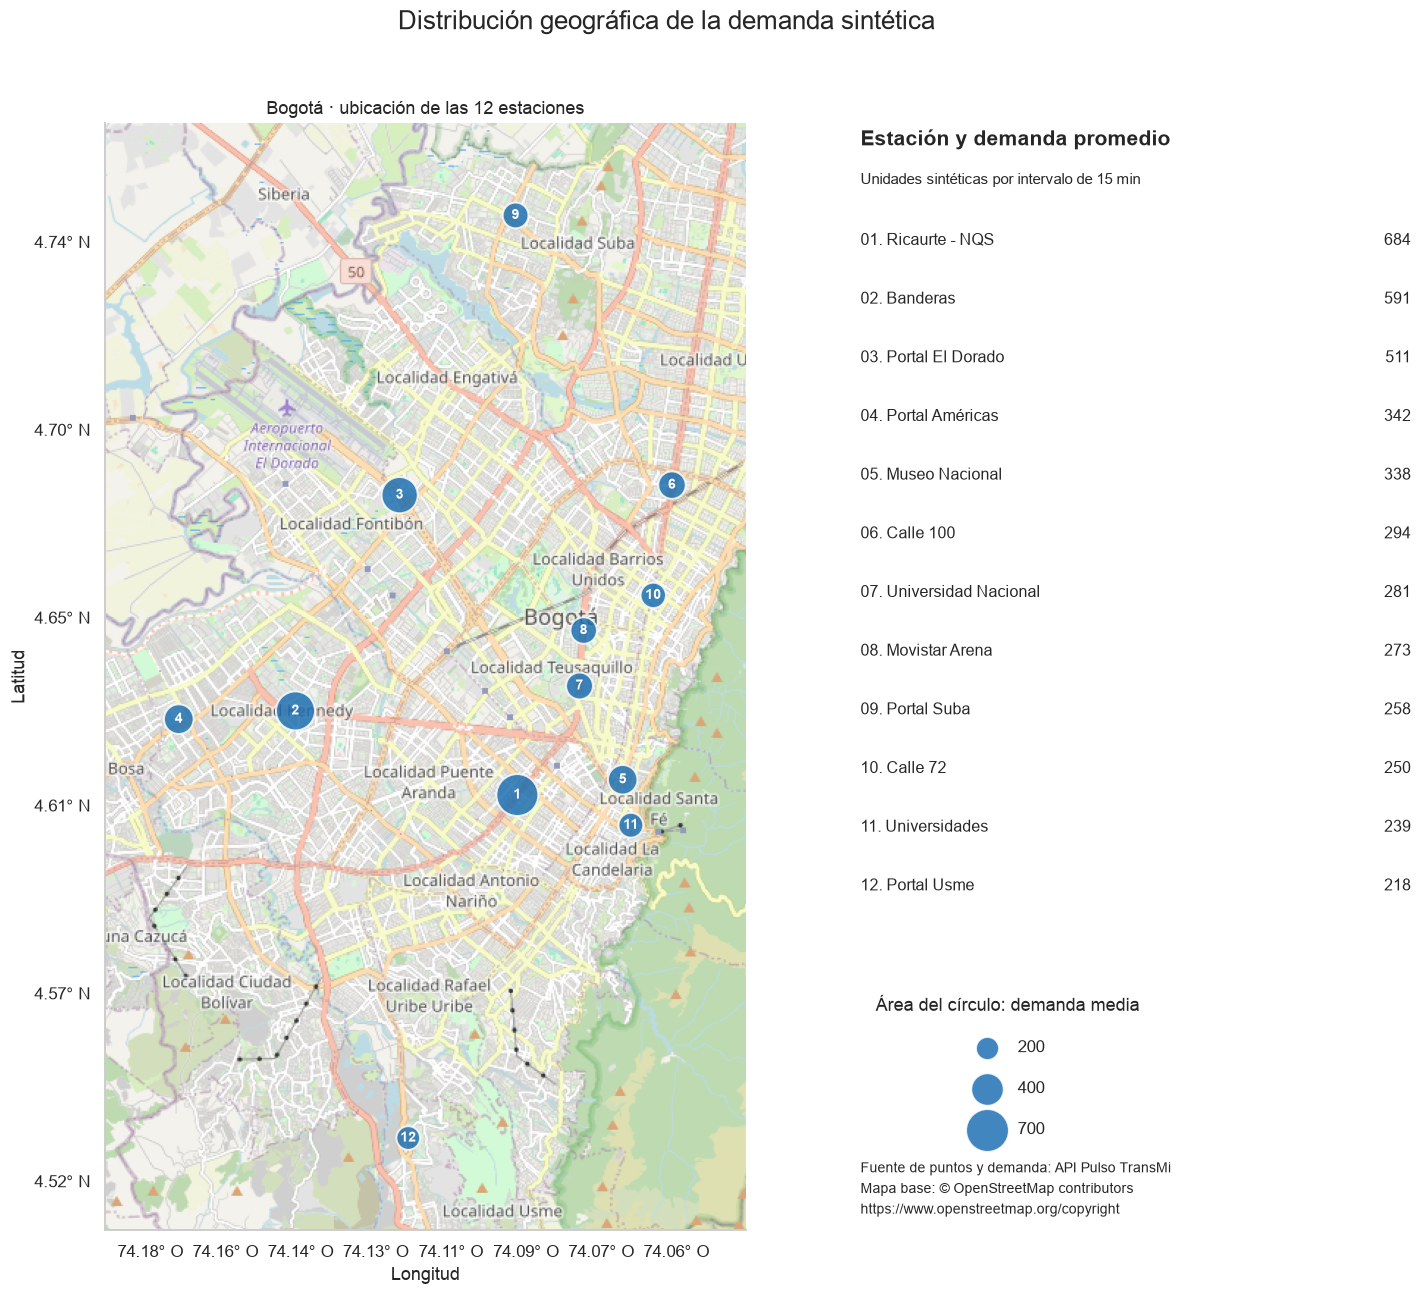

In [7]:
import math
import matplotlib.image as mpimg
from matplotlib.ticker import FuncFormatter

map_data = stations.merge(summary[["mean"]], left_on="station_id", right_index=True,
                          how="inner", validate="one_to_one").sort_values("mean", ascending=False).reset_index(drop=True)
assert len(map_data) == len(stations), "Faltan estaciones para el mapa."
assert np.isfinite(map_data[["latitude", "longitude", "mean"]].to_numpy()).all()

# Coordenadas normalizadas Web Mercator, iguales a las usadas por las teselas OSM.
zoom = 12
n_tiles = 2 ** zoom
def lon_to_x(lon):
    return (np.asarray(lon) + 180) / 360 * n_tiles
def lat_to_y(lat):
    radians = np.radians(np.asarray(lat))
    return (1 - np.arcsinh(np.tan(radians)) / np.pi) / 2 * n_tiles

def x_to_lon(x):
    return x / n_tiles * 360 - 180

def y_to_lat(y):
    return np.degrees(np.arctan(np.sinh(np.pi * (1 - 2 * y / n_tiles))))

map_data["x"] = lon_to_x(map_data.longitude)
map_data["y"] = lat_to_y(map_data.latitude)
xspan = map_data.x.max() - map_data.x.min()
yspan = map_data.y.max() - map_data.y.min()
xmin, xmax = map_data.x.min() - xspan * .15, map_data.x.max() + xspan * .15
ymin, ymax = map_data.y.min() - yspan * .10, map_data.y.max() + yspan * .10
x0, x1 = math.floor(xmin), math.floor(xmax)
y0, y1 = math.floor(ymin), math.floor(ymax)

fig, (ax, key) = plt.subplots(1, 2, figsize=(14, 12), gridspec_kw={"width_ratios": [1.65, 1]})
try:
    for tile_x in range(x0, x1 + 1):
        for tile_y in range(y0, y1 + 1):
            url = f"https://tile.openstreetmap.org/{zoom}/{tile_x}/{tile_y}.png"
            request = urllib.request.Request(url, headers={"User-Agent": "PulsoTransmi-EDA/1.0 (educational notebook; Python urllib)"})
            with urllib.request.urlopen(request, timeout=30, context=tls) as response:
                tile = mpimg.imread(io.BytesIO(response.read()), format="png")
            ax.imshow(tile, extent=(tile_x, tile_x + 1, tile_y + 1, tile_y), origin="upper", alpha=.80, zorder=0)
except Exception:
    plt.close(fig)
    raise RuntimeError("No se pudo cargar el mapa base de OpenStreetMap. Revisar la conexión y ejecutar esta celda otra vez.")

area_scale = 1.1  # Área en puntos cuadrados por unidad de demanda media.
ax.scatter(map_data.x, map_data.y, s=map_data["mean"] * area_scale,
           color="#176cb0", alpha=.82, edgecolors="white", linewidths=1.3, zorder=3)
for i, row in map_data.iterrows():
    ax.annotate(str(i + 1), (row.x, row.y), ha="center", va="center",
                fontsize=9, color="white", fontweight="bold", zorder=4)
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymax, ymin)
ax.set_aspect("equal")
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{abs(x_to_lon(x)):.2f}° O"))
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f"{y_to_lat(y):.2f}° N"))
ax.set(xlabel="Longitud", ylabel="Latitud", title="Bogotá · ubicación de las 12 estaciones")
ax.grid(False)

key.set_axis_off()
key.text(0, .98, "Estación y demanda promedio", fontsize=14, weight="bold", transform=key.transAxes)
key.text(0, .945, "Unidades sintéticas por intervalo de 15 min", fontsize=10, transform=key.transAxes)
for i, row in map_data.iterrows():
    yy = .89 - i * .053
    key.text(0, yy, f"{i + 1:02d}. {short[row.station_id]}", fontsize=10.5, transform=key.transAxes)
    key.text(.99, yy, f"{row['mean']:,.0f}", ha="right", fontsize=10.5, transform=key.transAxes)
legend_values = [200, 400, 700]
handles = [ax.scatter([], [], s=value * area_scale, color="#176cb0", alpha=.82,
                      edgecolors="white", label=str(value)) for value in legend_values]
key.legend(handles=handles, title="Área del círculo: demanda media", loc="lower left",
           bbox_to_anchor=(0, .07), labelspacing=1.5, frameon=False)
key.text(0, .015, "Fuente de puntos y demanda: API Pulso TransMi\nMapa base: © OpenStreetMap contributors\nhttps://www.openstreetmap.org/copyright",
         fontsize=9, transform=key.transAxes, linespacing=1.6)
fig.suptitle("Distribución geográfica de la demanda sintética", fontsize=17, y=.98)
plt.tight_layout(rect=(0, 0, 1, .96))
plt.show()


## 5. Estacionalidad diaria, semanal y perfiles individuales
El promedio general puede esconder estaciones con picos distintos y cambios de fin de semana en sentido contrario. Los perfiles horarios promedian los cuatro intervalos de cada hora; no son sumas horarias.

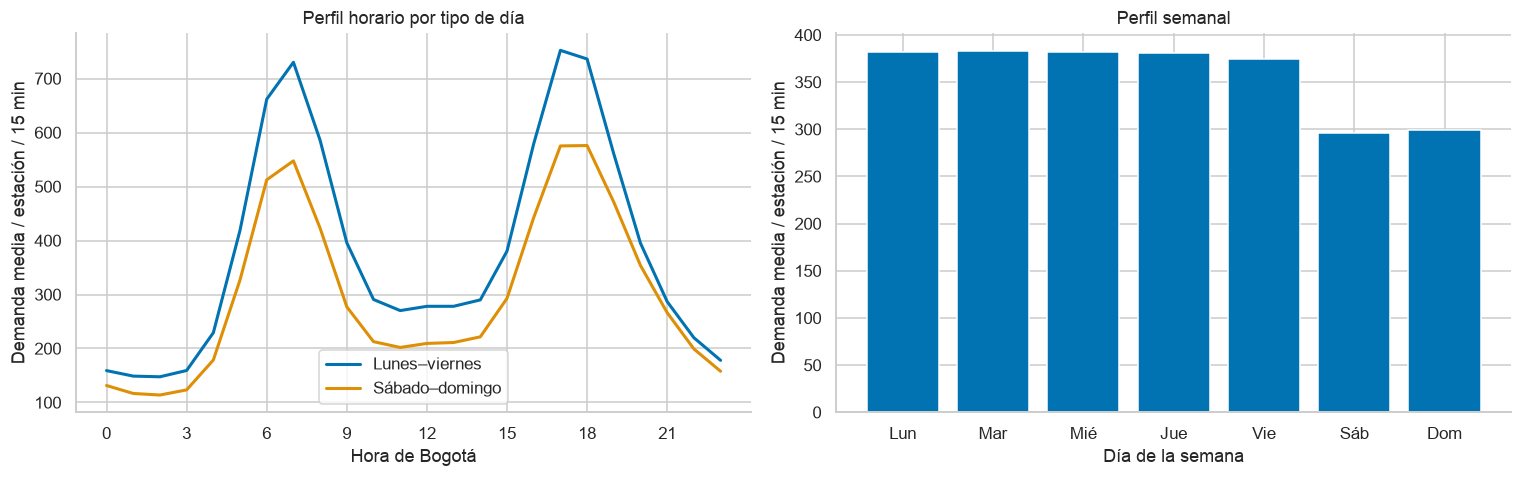

Cambio global de fin de semana: -21.8%.


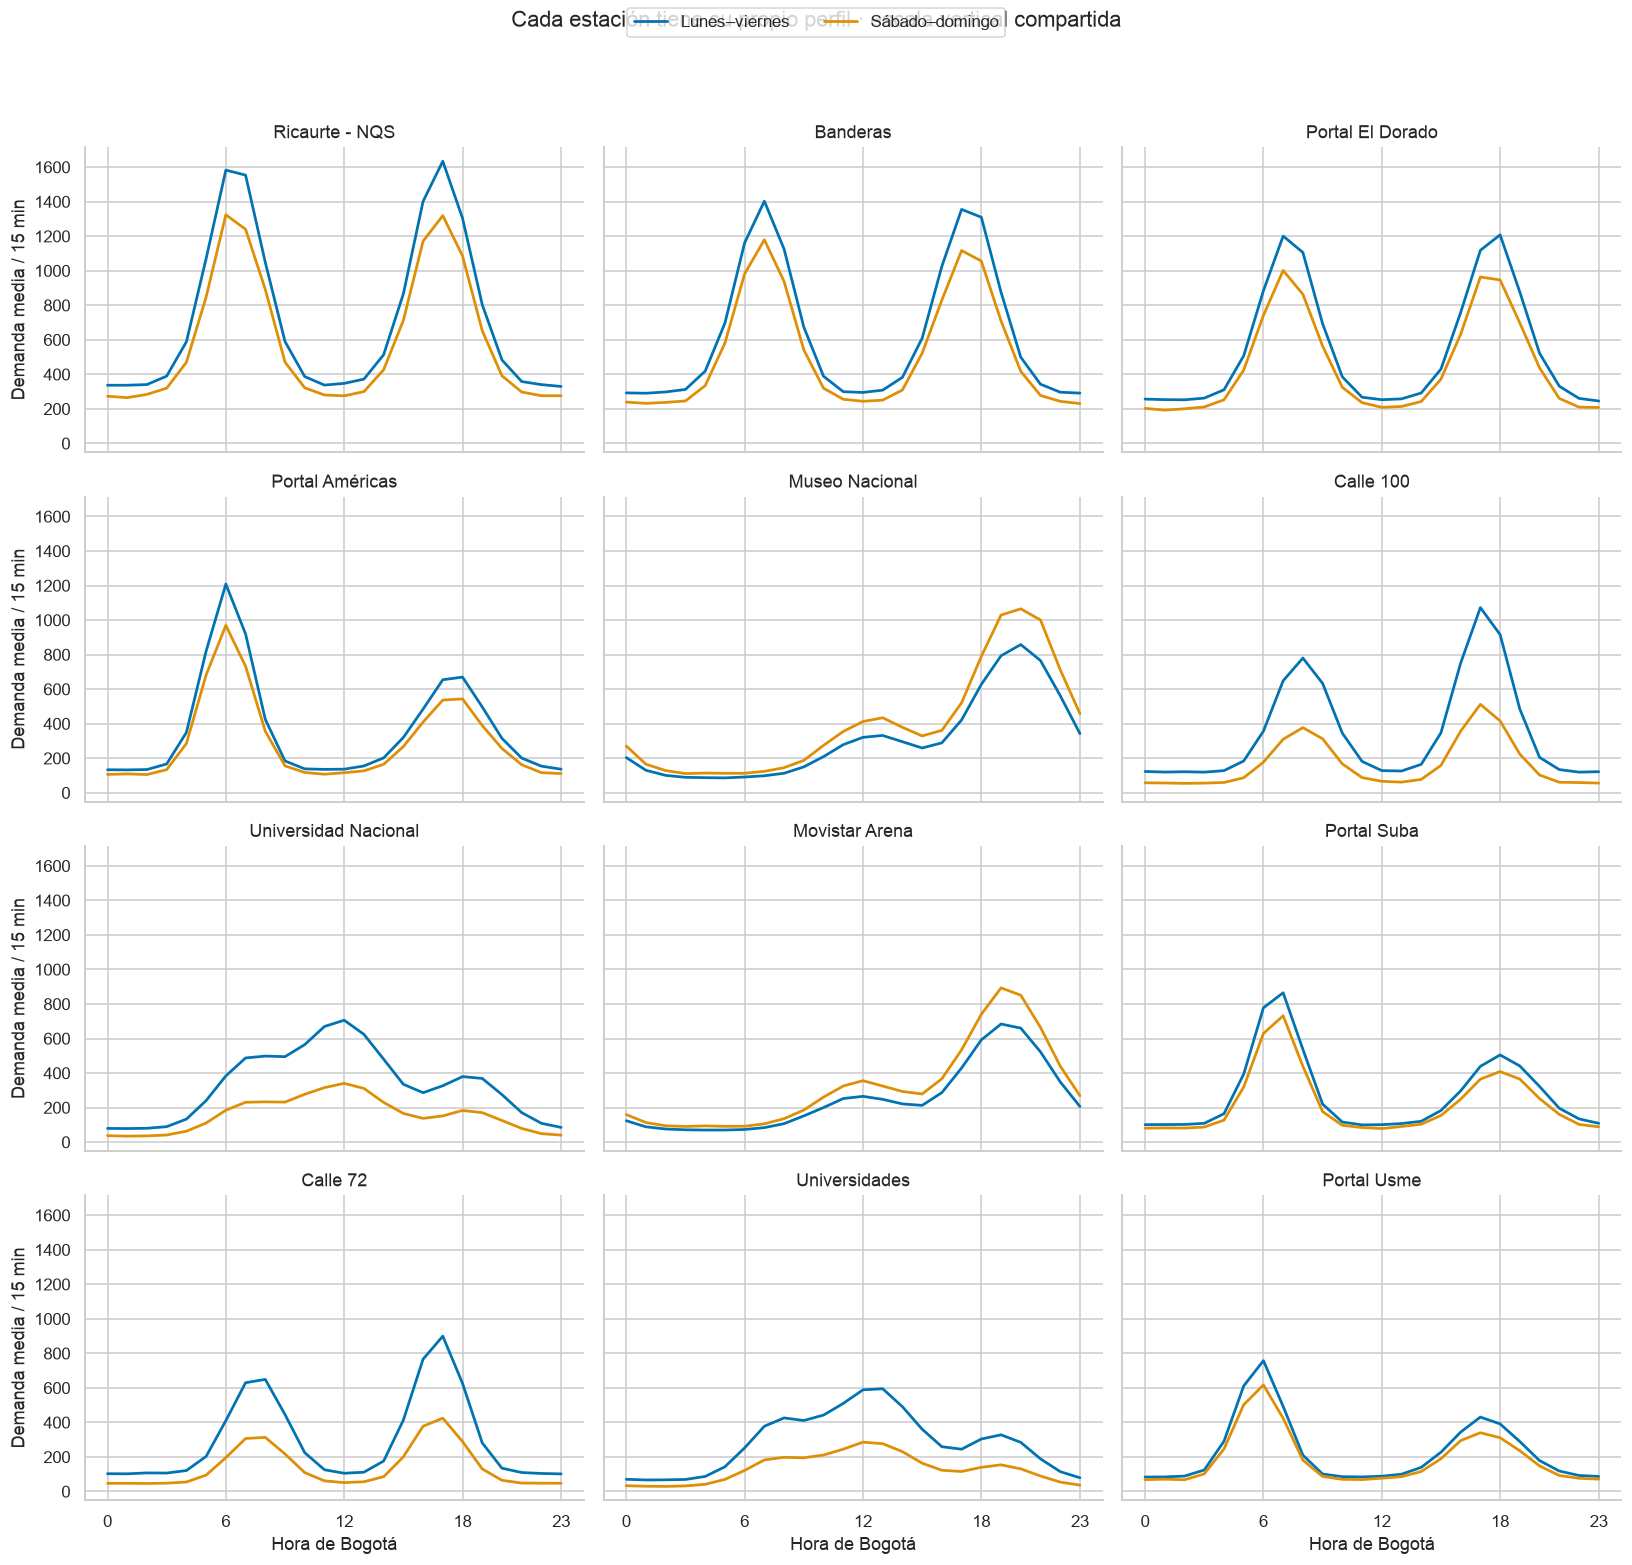

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
hourly = data.groupby(["hour", "day_type"]).demand.mean().unstack()
hourly.plot(ax=axes[0], linewidth=2)
axes[0].set(title="Perfil horario por tipo de día", xlabel="Hora de Bogotá", ylabel="Demanda media / estación / 15 min", xticks=range(0, 24, 3))
axes[0].legend(title="")
weekday = data.groupby("dow").demand.mean().reindex(range(7))
axes[1].bar(["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"], weekday)
axes[1].set(title="Perfil semanal", xlabel="Día de la semana", ylabel="Demanda media / estación / 15 min")
plt.tight_layout()
plt.show()
daymeans = data.groupby("weekend").demand.mean()
print(f"Cambio global de fin de semana: {(daymeans.loc[True] / daymeans.loc[False] - 1) * 100:.1f}%.")

fig, axes = plt.subplots(4, 3, figsize=(15, 14), sharex=True, sharey=True)
for ax, sid in zip(axes.flat, summary.index):
    p = data.loc[data.station_id.eq(sid)].groupby(["hour", "day_type"]).demand.mean().unstack()
    p.plot(ax=ax, legend=False, linewidth=1.8)
    ax.set(title=short[sid], xlabel="Hora de Bogotá", ylabel="Demanda media / 15 min", xticks=[0, 6, 12, 18, 23])
handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2)
fig.suptitle("Cada estación tiene su propio perfil · escala vertical compartida", y=1.015)
plt.tight_layout(rect=(0, 0, 1, .98))
plt.show()

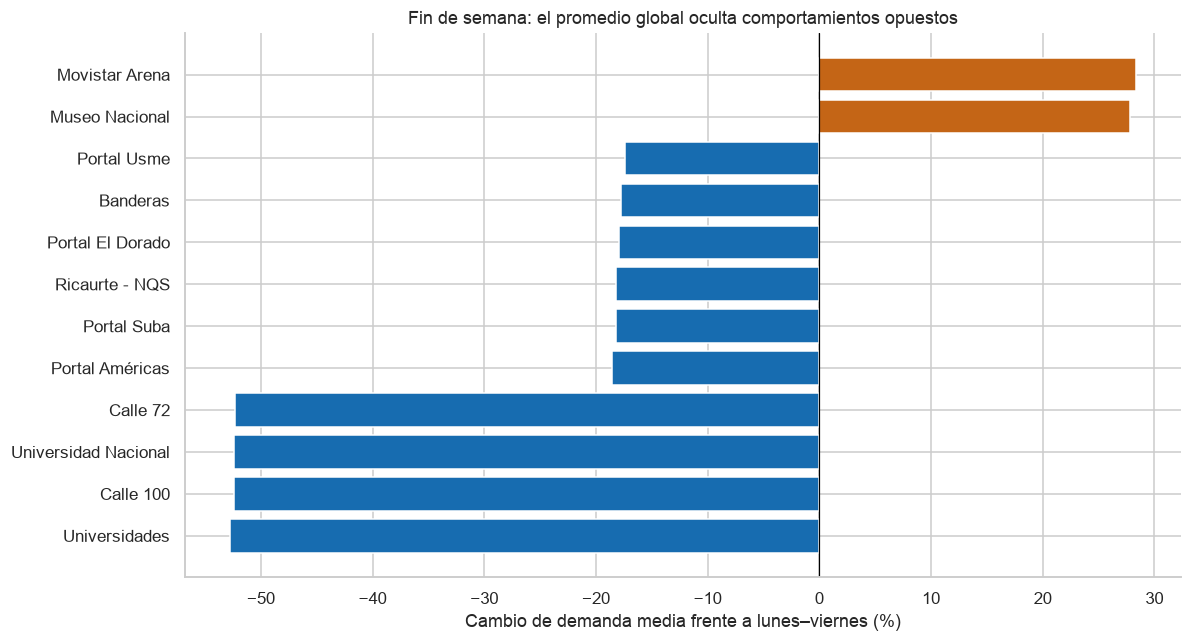

,lunes_viernes,sabado_domingo,cambio_pct,estacion
station_id,,,,
06111,281.870,133.090,-52.780,Universidades – CityU
02300,346.450,164.790,-52.430,Calle 100 - Marketmedios
07107,331.150,157.650,-52.390,Universidad Nacional
09122,294.250,140.380,-52.290,Calle 72
05000,361.460,294.290,-18.580,Portal Américas
03000,272.760,223.150,-18.190,Portal Suba
07111,721.580,590.520,-18.160,Ricaurte - NQS
06000,538.930,442.040,-17.980,Portal El Dorado – C.C. NUESTRO BOGOTÁ
05100,623.080,512.250,-17.790,Banderas


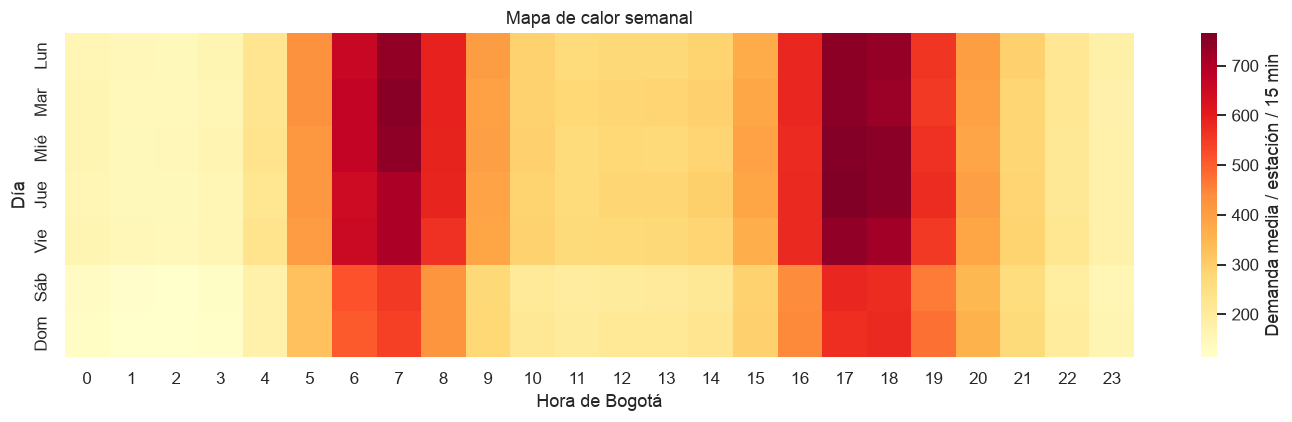

In [9]:
weekend = data.groupby(["station_id", "weekend"]).demand.mean().unstack()
weekend.columns = ["lunes_viernes", "sabado_domingo"]
weekend["cambio_pct"] = (weekend.sabado_domingo / weekend.lunes_viernes - 1) * 100
weekend = weekend.sort_values("cambio_pct")
fig, ax = plt.subplots(figsize=(11, 6))
ax.barh([short[k] for k in weekend.index], weekend.cambio_pct,
        color=["#176cb0" if v < 0 else "#c46516" for v in weekend.cambio_pct])
ax.axvline(0, color="black", linewidth=.8)
ax.set(title="Fin de semana: el promedio global oculta comportamientos opuestos",
       xlabel="Cambio de demanda media frente a lunes–viernes (%)", ylabel="")
plt.tight_layout()
plt.show()
display(weekend.assign(estacion=weekend.index.map(names)).round(2))

heat = data.groupby(["dow", "hour"]).demand.mean().unstack().reindex(range(7))
fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(heat, cmap="YlOrRd", yticklabels=["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"],
            cbar_kws={"label": "Demanda media / estación / 15 min"}, ax=ax)
ax.set(title="Mapa de calor semanal", xlabel="Hora de Bogotá", ylabel="Día")
plt.tight_layout()
plt.show()

## 6. Evolución temporal: comparar semanas completas
Los extremos del corte contienen semanas incompletas. Se muestran todos los días, pero solo se comparan totales semanales cuando hay siete días completos. Un cambio visual no constituye una prueba de drift.

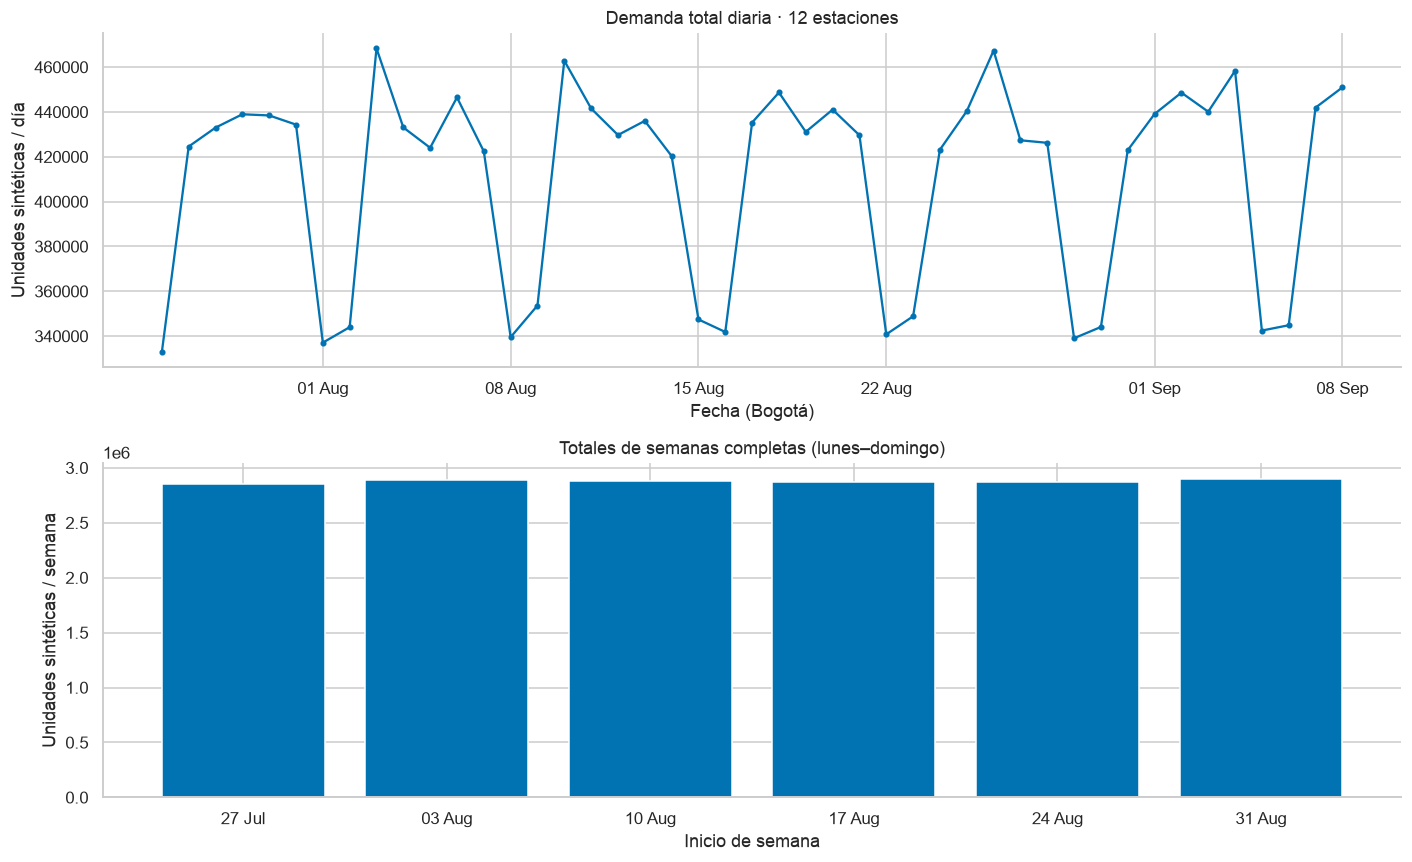

,dias,total,media
week_start,,,
2026-07-20 00:00:00-05:00,1,332887,288.964
2026-07-27 00:00:00-05:00,7,2850295,353.459
2026-08-03 00:00:00-05:00,7,2887470,358.069
2026-08-10 00:00:00-05:00,7,2879652,357.100
2026-08-17 00:00:00-05:00,7,2875258,356.555
2026-08-24 00:00:00-05:00,7,2867463,355.588
2026-08-31 00:00:00-05:00,7,2896294,359.163
2026-09-07 00:00:00-05:00,2,892827,387.512


Rango entre mayor y menor total semanal: 1.61%.


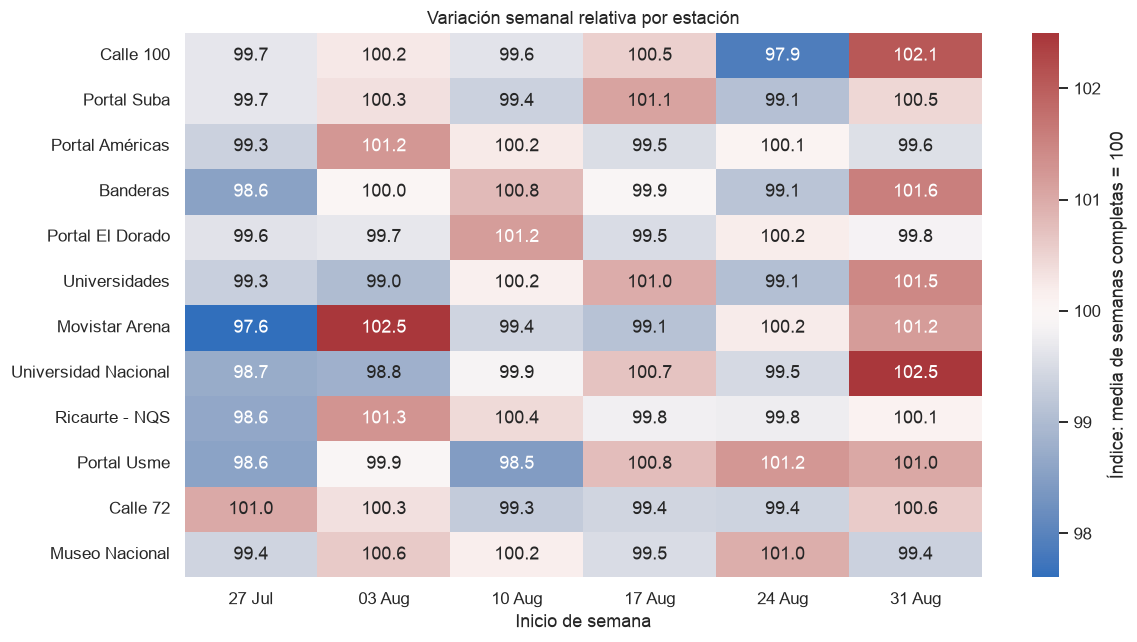

In [10]:
daily = data.groupby("date").demand.sum()
weekly = data.groupby("week_start").agg(dias=("date", "nunique"), total=("demand", "sum"), media=("demand", "mean"))
complete = weekly.loc[weekly.dias.eq(7)]
fig, axes = plt.subplots(2, 1, figsize=(13, 8))
axes[0].plot(daily.index, daily.values, marker=".", linewidth=1.5)
axes[0].set(title="Demanda total diaria · 12 estaciones", xlabel="Fecha (Bogotá)", ylabel="Unidades sintéticas / día")
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%d %b", tz=TZ))
if not complete.empty:
    axes[1].bar(complete.index.strftime("%d %b"), complete.total)
axes[1].set(title="Totales de semanas completas (lunes–domingo)", xlabel="Inicio de semana", ylabel="Unidades sintéticas / semana")
plt.tight_layout()
plt.show()
display(weekly)
if not complete.empty:
    print(f"Rango entre mayor y menor total semanal: {(complete.total.max() / complete.total.min() - 1) * 100:.2f}%.")
station_weeks = data.loc[data.week_start.isin(complete.index)].groupby(["station_id", "week_start"]).demand.mean().unstack()
normalized = station_weeks.div(station_weeks.mean(axis=1), axis=0).mul(100)
normalized.index = normalized.index.map(short)
normalized.columns = normalized.columns.strftime("%d %b")
fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(normalized, cmap="vlag", center=100, annot=True, fmt=".1f",
            cbar_kws={"label": "Índice: media de semanas completas = 100"}, ax=ax)
ax.set(title="Variación semanal relativa por estación", xlabel="Inicio de semana", ylabel="")
plt.tight_layout()
plt.show()

## 7. Extremos: marcar, no borrar
Se aplica la regla exploratoria Q1 − 1,5×IQR / Q3 + 1,5×IQR por estación. Esta regla ignora hora y día; puede señalar demanda alta perfectamente coherente con horas punta. No se modifica ninguna observación.

,marcados,fraccion
station_name,,
Banderas,19,0.004
Calle 100 - Marketmedios,298,0.069
Calle 72,281,0.065
Movistar Arena,191,0.044
Museo Nacional,213,0.049
Portal Américas,201,0.047
Portal El Dorado – C.C. NUESTRO BOGOTÁ,30,0.007
Portal Suba,204,0.047
Portal Usme,205,0.047


,station_name,observed_at,demand,rain_mm,event_intensity,iqr_flag
35685,Ricaurte - NQS,2026-08-06 17:15:00-05:00,2284,0.002,0.000,True
37123,Ricaurte - NQS,2026-08-21 16:45:00-05:00,2255,0.000,0.000,True
36221,Ricaurte - NQS,2026-08-12 07:15:00-05:00,2199,0.004,0.000,True
35452,Ricaurte - NQS,2026-08-04 07:00:00-05:00,2180,0.042,0.006,True
36989,Ricaurte - NQS,2026-08-20 07:15:00-05:00,2178,0.219,0.000,True
36408,Ricaurte - NQS,2026-08-14 06:00:00-05:00,2173,0.002,0.000,True
35109,Ricaurte - NQS,2026-07-31 17:15:00-05:00,2139,0.060,0.000,True
36699,Ricaurte - NQS,2026-08-17 06:45:00-05:00,2138,0.696,0.000,True
38471,Ricaurte - NQS,2026-09-04 17:45:00-05:00,2104,0.005,0.849,True
38043,Ricaurte - NQS,2026-08-31 06:45:00-05:00,2103,0.171,0.000,True


Marcados por IQR: 1,690 (3.26%).


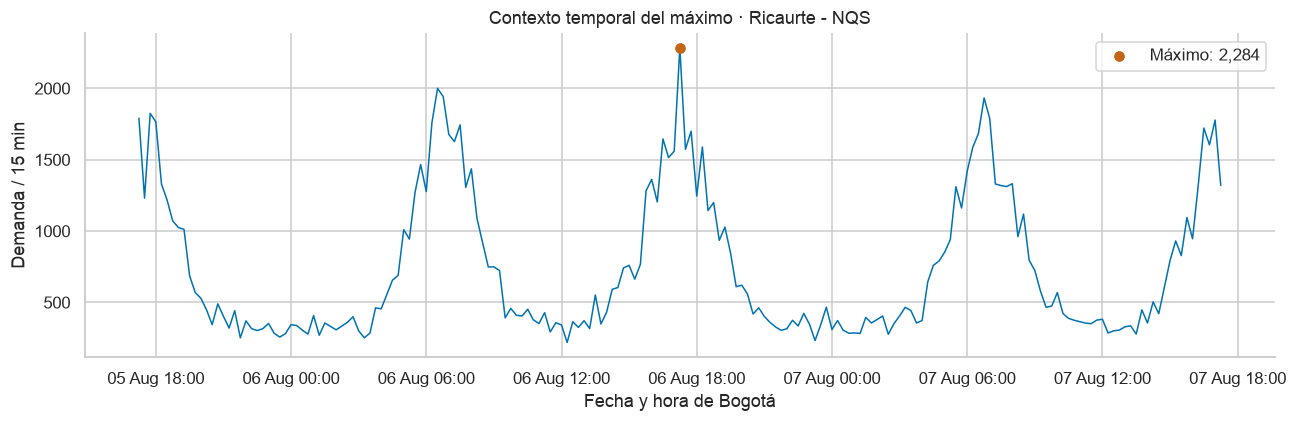

In [11]:
quartiles = data.groupby("station_id").demand.quantile([.25, .75]).unstack()
quartiles.columns = ["q1", "q3"]
ext = data.join(quartiles, on="station_id")
iqr = ext.q3 - ext.q1
ext["iqr_flag"] = (ext.demand < ext.q1 - 1.5 * iqr) | (ext.demand > ext.q3 + 1.5 * iqr)
display(ext.groupby("station_name").iqr_flag.agg(["sum", "mean"]).rename(columns={"sum": "marcados", "mean": "fraccion"}))
display(ext.nlargest(10, "demand")[["station_name", "observed_at", "demand", "rain_mm", "event_intensity", "iqr_flag"]])
print(f"Marcados por IQR: {ext.iqr_flag.sum():,} ({100 * ext.iqr_flag.mean():.2f}%).")
peak = ext.loc[ext.demand.idxmax()]
window = ext.loc[ext.station_id.eq(peak.station_id) & (ext.observed_at - peak.observed_at).abs().le(pd.Timedelta(days=1))]
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(window.observed_at, window.demand, linewidth=1)
ax.scatter([peak.observed_at], [peak.demand], color="#c46516", zorder=3, label=f"Máximo: {peak.demand:,.0f}")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b %H:%M", tz=TZ))
ax.set(title=f"Contexto temporal del máximo · {short[peak.station_id]}", xlabel="Fecha y hora de Bogotá", ylabel="Demanda / 15 min")
ax.legend()
plt.tight_layout()
plt.show()

## 8. Clima y eventos
El contexto se analiza con sus **4.320 timestamps**, sin multiplicar artificialmente sus observaciones por 12 estaciones. Las comparaciones observado/pronóstico usan el mismo timestamp: no son una validación de pronósticos futuros, porque falta el contrato de emisión/horizonte.

En eventos se muestran umbrales descriptivos elegidos para explorar. No representan categorías oficiales ni eventos independientes.

,count,mean,std,min,50%,90%,95%,99%,max
rain_mm,"4,320.000",0.260,0.516,0.000,0.062,0.741,1.171,2.533,7.722
rain_forecast,"4,320.000",0.381,0.569,0.000,0.178,1.009,1.376,2.705,7.461
temperature_c,"4,320.000",14.507,4.180,6.753,14.519,20.005,20.515,21.234,22.321
temperature_forecast,"4,320.000",14.506,4.258,5.449,14.453,20.144,20.767,21.860,23.568
event_intensity,"4,320.000",0.032,0.147,0.000,0.000,0.000,0.135,0.912,1.000


,umbral_intensidad,intervalos_por_encima
0,0.000,3867
1,0.010,335
2,0.100,239
3,0.500,129
4,0.900,53


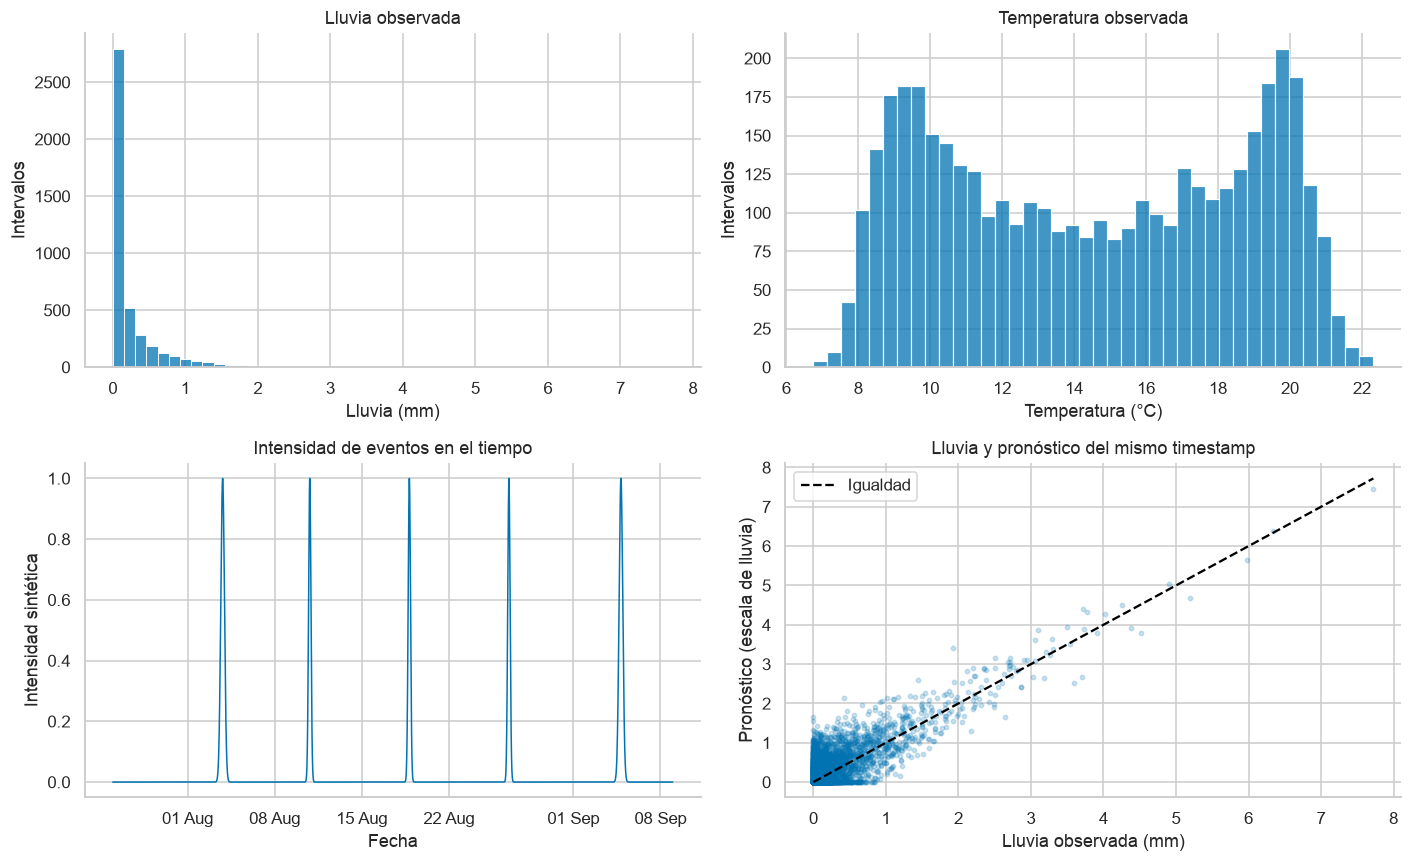

,intensidad_maxima_del_dia
observed_at,
2026-08-03,1.000
2026-08-10,1.000
2026-08-18,1.000
2026-08-26,1.000
2026-09-04,1.000


In [12]:
weather = ["rain_mm", "rain_forecast", "temperature_c", "temperature_forecast", "event_intensity"]
display(context[weather].describe(percentiles=[.5, .9, .95, .99]).T)
display(pd.DataFrame({
    "umbral_intensidad": [0, .01, .1, .5, .9],
    "intervalos_por_encima": [int(context.event_intensity.gt(t).sum()) for t in [0, .01, .1, .5, .9]]
}))
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
sns.histplot(context.rain_mm, bins=50, ax=axes[0, 0])
axes[0, 0].set(title="Lluvia observada", xlabel="Lluvia (mm)", ylabel="Intervalos")
sns.histplot(context.temperature_c, bins=40, ax=axes[0, 1])
axes[0, 1].set(title="Temperatura observada", xlabel="Temperatura (°C)", ylabel="Intervalos")
axes[1, 0].plot(context.observed_at, context.event_intensity, linewidth=1)
axes[1, 0].set(title="Intensidad de eventos en el tiempo", xlabel="Fecha", ylabel="Intensidad sintética")
axes[1, 0].xaxis.set_major_formatter(mdates.DateFormatter("%d %b", tz=TZ))
axes[1, 1].scatter(context.rain_mm, context.rain_forecast, alpha=.2, s=8)
limit = max(context.rain_mm.max(), context.rain_forecast.max())
axes[1, 1].plot([0, limit], [0, limit], linestyle="--", color="black", label="Igualdad")
axes[1, 1].set(title="Lluvia y pronóstico del mismo timestamp", xlabel="Lluvia observada (mm)", ylabel="Pronóstico (escala de lluvia)")
axes[1, 1].legend()
plt.tight_layout()
plt.show()
event_daily = context.groupby(context.observed_at.dt.strftime("%Y-%m-%d")).event_intensity.max()
display(event_daily.loc[event_daily.gt(.5)].to_frame("intensidad_maxima_del_dia"))

## 9. Asociaciones: antes y después de descontar el calendario
Para cada variable se resta su media dentro del grupo **estación × día de semana × intervalo del día**. Se correlacionan los residuos para explorar asociaciones que quedan después de esos patrones.

Es un ajuste descriptivo dentro de esta muestra, con solo seis o siete repeticiones por grupo. **No prueba causalidad, significancia ni valor predictivo.** No debe copiarse al entrenamiento usando toda la historia: los promedios tendrían que ajustarse solo con el pasado. La dependencia temporal y el contexto compartido impiden tratar las 51.840 filas como observaciones independientes.

,Sin ajuste,Con ajuste calendario/estación
rain_mm,-0.010,-0.091
rain_forecast,-0.008,-0.069
temperature_c,0.208,-0.001
temperature_forecast,0.205,-0.006
event_intensity,0.088,0.162


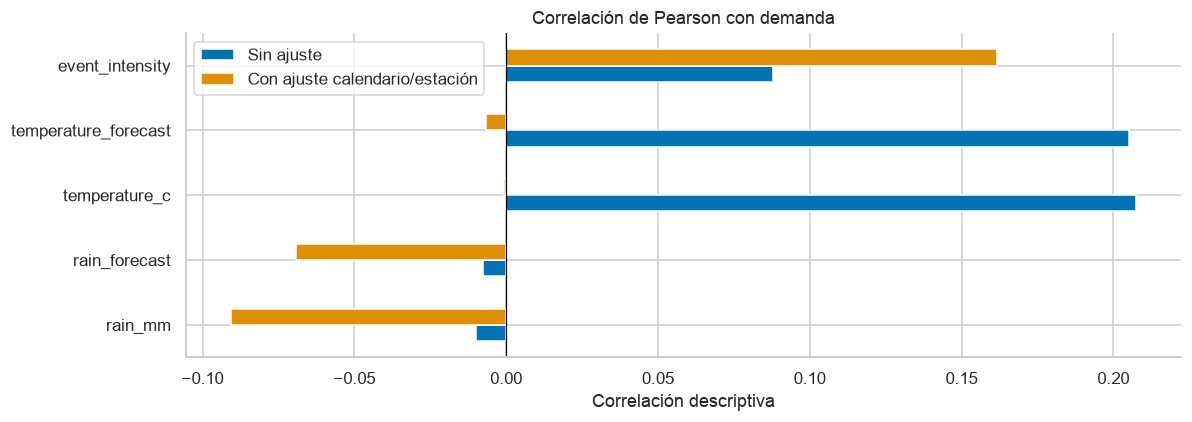

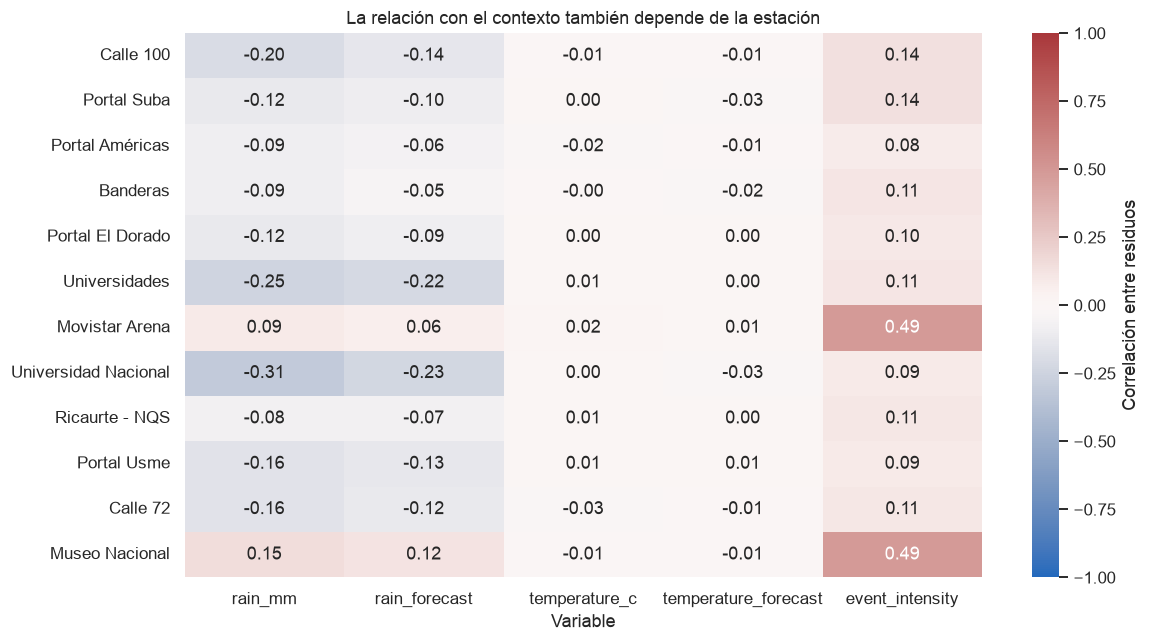

In [13]:
variables = ["demand"] + weather
raw_corr = data[variables].corr()["demand"].drop("demand")
residuals = data[variables] - data.groupby(["station_id", "dow", "slot"])[variables].transform("mean")
adjusted_corr = residuals.corr()["demand"].drop("demand")
comparison = pd.DataFrame({"Sin ajuste": raw_corr, "Con ajuste calendario/estación": adjusted_corr})
display(comparison)
fig, ax = plt.subplots(figsize=(11, 4))
comparison.plot.barh(ax=ax)
ax.axvline(0, color="black", linewidth=.8)
ax.set(title="Correlación de Pearson con demanda", xlabel="Correlación descriptiva", ylabel="")
ax.legend(loc="best")
plt.tight_layout()
plt.show()
residuals["station_id"] = data.station_id
station_corr = pd.DataFrame({
    sid: g[variables].corr()["demand"].drop("demand")
    for sid, g in residuals.groupby("station_id")
}).T
station_corr.index = station_corr.index.map(short)
fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(station_corr, annot=True, fmt=".2f", vmin=-1, vmax=1, cmap="vlag", center=0,
            cbar_kws={"label": "Correlación entre residuos"}, ax=ax)
ax.set(title="La relación con el contexto también depende de la estación", xlabel="Variable", ylabel="")
plt.tight_layout()
plt.show()

## 10. Dependencia temporal por estación
Se usan rezagos de 1, 4, 96 y 672 registros, equivalentes a 15 minutos, 1 hora, 1 día y 1 semana **solo después de verificar la continuidad de 15 minutos**. Cada correlación usa los pares disponibles; los rezagos largos tienen menos pares. No es una comparación de modelos ni de errores de pronóstico.

,15 min,1 hora,1 día,1 semana,estacion
station_id,,,,,
02300,0.941,0.761,0.845,0.948,Calle 100 - Marketmedios
03000,0.947,0.736,0.944,0.957,Portal Suba
05000,0.943,0.733,0.943,0.956,Portal Américas
05100,0.934,0.757,0.923,0.939,Banderas
06000,0.920,0.745,0.913,0.931,Portal El Dorado – C.C. NUESTRO BOGOTÁ
06111,0.942,0.883,0.788,0.941,Universidades – CityU
07105,0.943,0.867,0.903,0.926,Movistar Arena
07107,0.947,0.887,0.792,0.940,Universidad Nacional
07111,0.929,0.748,0.923,0.939,Ricaurte - NQS


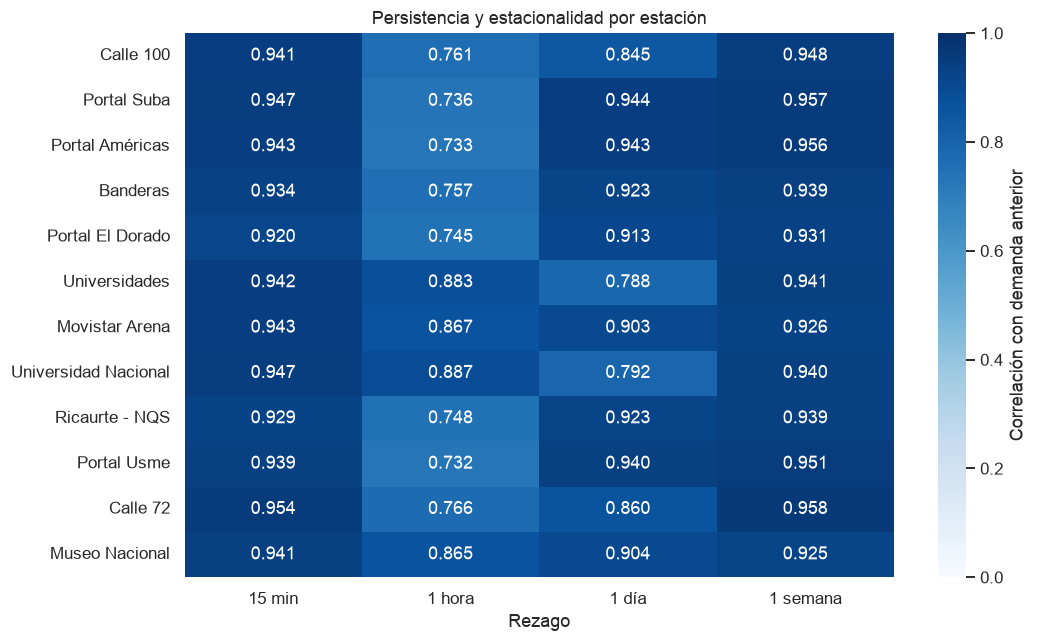

In [14]:
if meta["dataset"]["frequency_minutes"] != 15:
    raise ValueError("Adaptar rezagos: el corte ya no tiene frecuencia de 15 minutos.")
lag_rows = []
for sid, group in data.groupby("station_id", sort=True):
    group = group.sort_values("observed_at")
    row = {"station_id": sid}
    for lag, label in [(1, "15 min"), (4, "1 hora"), (96, "1 día"), (672, "1 semana")]:
        row[label] = group.demand.corr(group.demand.shift(lag))
    lag_rows.append(row)
lags = pd.DataFrame(lag_rows).set_index("station_id")
display(lags.assign(estacion=lags.index.map(names)))
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(lags.rename(index=short), annot=True, fmt=".3f", vmin=0, vmax=1, cmap="Blues",
            cbar_kws={"label": "Correlación con demanda anterior"}, ax=ax)
ax.set(title="Persistencia y estacionalidad por estación", xlabel="Rezago", ylabel="")
plt.tight_layout()
plt.show()

## 11. Conclusiones del corte y decisiones
Las cifras siguientes se calculan al ejecutar; no están escritas como constantes.

In [15]:
up = weekend.loc[weekend.cambio_pct.gt(0)]
down = weekend.loc[weekend.cambio_pct.lt(-40)]
report = [
    f"- Se examinaron **{len(observations):,} observaciones**, **{len(stations)} estaciones** y **{len(context):,} registros de contexto**.",
    f"- Faltantes de demanda en la grilla: **{coverage.intervalos_faltantes.sum()}**. Nulos originales: **{quality.nulos.sum()}**. No se imputaron ni eliminaron registros.",
    f"- Media de demanda: **{data.demand.mean():.1f}**; mediana: **{data.demand.median():.0f}**; máximo: **{data.demand.max():.0f}**. Los extremos requieren contexto temporal.",
    f"- Fin de semana global: **{(daymeans.loc[True] / daymeans.loc[False] - 1) * 100:.1f}%** frente a lunes–viernes.",
    "- Estaciones que aumentan el fin de semana: " + "; ".join(f"**{short[sid]} ({r.cambio_pct:+.1f}%)**" for sid, r in up.iterrows()) + ".",
    "- Estaciones con caída superior al 40%: " + "; ".join(f"{short[sid]} ({r.cambio_pct:.1f}%)" for sid, r in down.iterrows()) + ".",
    f"- Correlación temperatura/demanda: **{raw_corr.temperature_c:.3f}** sin ajuste y **{adjusted_corr.temperature_c:.3f}** tras descontar calendario y estación: la asociación global se reduce notablemente.",
    f"- La correlación semanal supera a la diaria en **{int(lags['1 semana'].gt(lags['1 día']).sum())} de {len(lags)} estaciones**; merece evaluarse un baseline semanal mediante backtesting."
]
display(Markdown("\n".join(report)))

- Se examinaron **51,840 observaciones**, **12 estaciones** y **4,320 registros de contexto**.
- Faltantes de demanda en la grilla: **0**. Nulos originales: **0**. No se imputaron ni eliminaron registros.
- Media de demanda: **356.5**; mediana: **263**; máximo: **2284**. Los extremos requieren contexto temporal.
- Fin de semana global: **-21.8%** frente a lunes–viernes.
- Estaciones que aumentan el fin de semana: **Museo Nacional (+27.8%)**; **Movistar Arena (+28.4%)**.
- Estaciones con caída superior al 40%: Universidades (-52.8%); Calle 100 (-52.4%); Universidad Nacional (-52.4%); Calle 72 (-52.3%).
- Correlación temperatura/demanda: **0.208** sin ajuste y **-0.001** tras descontar calendario y estación: la asociación global se reduce notablemente.
- La correlación semanal supera a la diaria en **12 de 12 estaciones**; merece evaluarse un baseline semanal mediante backtesting.

### Implicaciones para la siguiente etapa
1. Conservar el corte íntegro: no rellenar ni borrar valores sin evidencia.
2. Diseñar variables de hora, día de semana y estación, y comparar rezagos diarios y semanales. Los perfiles de universidad, portales y estaciones con mayor actividad nocturna son distintos en esta muestra.
3. Evaluar por estación y horizonte; un agregado global es insuficiente.
4. Investigar lluvia y eventos por estación. La correlación global puede esconder asociaciones opuestas.
5. Comparar períodos con la misma composición semanal antes de interpretar cambios como drift.
6. Reservar una ventana final sin usarla para seleccionar modelos. Este EDA examinó toda la historia disponible: por ello, cualquier evaluación posterior sobre el mismo corte debe reconocer ese uso exploratorio y apoyarse en backtesting o nuevos datos.

### Información que falta
- Definición operacional precisa de `demand` y su relación con entradas/salidas o pasajeros.
- Horario real, capacidad, frecuencia de buses, cierres, interrupciones y etiqueta de festivo.
- Clima/eventos específicos por estación y definición de `event_intensity`.
- Emisión, horizonte y disponibilidad real de los pronósticos meteorológicos.
- Duración de los cuatro horizontes competitivos y contrato de envío.
- Historia suficiente para estacionalidad mensual/anual. Los 45 días iniciales solo aportan seis semanas completas.

### Límites
Los datos son sintéticos y contienen demanda positiva de madrugada: no se extrapolan a operación real. Las asociaciones no son causales. La estabilidad de medias semanales no descarta cambios en distribución o desempeño. Este notebook realiza EDA; no entrena modelos ni envía predicciones.

Fuentes: [metadatos públicos](https://pulso-transmi.72-60-245-2.sslip.io/v1/meta), [contrato API](https://pulso-transmi.72-60-245-2.sslip.io/docs), [README del SDK](../README.md) y [guía del proyecto](../docs/student-project.md).